In [ ]:
import numpy as np
import pandas as pd
import networkx as nx
import matplotlib
import matplotlib.pyplot as plt
import torch
import fantom
import pyro.distributions as distrib
import torch.distributions as td
import torch.nn as nn
from metrics import shd, classification_metrics, threshold_metrics
from sklearn.metrics import accuracy_score,roc_auc_score
from torch.utils.data import DataLoader

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import matplotlib.colors as mcolors
device = "cuda:0" if torch.cuda.is_available() else "cpu"

# Synthetic Data generation:

In [82]:
from generate_nonlin_diff_var import gen_stationary_dyn_net_and_df_regime

In [83]:
n_nodes = 10
reg = np.random.choice(np.array([1500,2000,2500,3000]),2)
reg

array([2500, 3000])

In [ ]:
g_list,df_total, intra_nodes, inter_nodes = gen_stationary_dyn_net_and_df_regime(2,[np.exp, np.tanh, np.exp],n_nodes,reg,1,4,2,w_max_inter=1,w_min_inter=0,
                                                                                 w_max_intra=1,w_min_intra=0,
                                                                                 graph_type_intra = "barabasi-albert",
                                                                                 graph_type_inter = "erdos-renyi",
                                                                                 noise_scale = [1,1,1],
                                                                                 max_data_gen_trials = 1000,
                                                                                 sem_type = "heteroscedastic")

In [85]:

lag = False
if lag == True:
            rearange_intra = [str(i)+"_lag0" for i in range(n_nodes)]
            rearange_inter1 = [str(i)+"_lag1" for i in range(n_nodes)]
            rearange_inter2 = [str(i)+"_lag2" for i in range(n_nodes)]
            rearange_inter = rearange_inter1 + rearange_inter2
else:
            rearange_intra = [str(i)+"_lag0" for i in range(n_nodes)]
            rearange_inter = [str(i)+"_lag1" for i in range(n_nodes)]

In [86]:
data = df_total[rearange_inter+rearange_intra].to_numpy()
data = data.reshape((reg.sum(),2,n_nodes))
#data[:,0,:] = (data[:,0,:] -data[:,0,:].mean())/data[:,0,:].std()
#data[:,1,:] = (data[:,1,:] -data[:,1,:].mean())/data[:,1,:].std()

# Fantom: 

In [87]:
dataset_config = {'dataset_format': 'temporal_causal_csv', 'use_predefined_dataset': True, 'test_fraction': 0.0, 
                  'val_fraction': 0.0, 'random_seed': 0, 'negative_sample': False}
model_config = {'tau_gumbel': 0.25, 'lambda_dag': 1.0, 'lambda_sparse': 50.0, 'spline_bins': 128, 
                'encoder_layer_sizes':[32,32],'decoder_layer_sizes':[32,32],
                'var_dist_A_mode': 'temporal_three', "heteroscedastic":False,#'mode_adjacency': 'learn', 
                'norm_layers': True, 'res_connection': True, 'base_distribution_type': "conditional_spline"}
# To speed up training you can try:
#  increasing learning_rate
#  increasing batch_size (reduces noise when using higher learning rate)
#  decreasing max_steps_auglag (go as low as you can and still get a DAG)
#  decreasing max_auglag_inner_epochs
training_params = {'learning_rate': 0.005, 'batch_size': 256, 'stardardize_data_mean': False, 
                   'stardardize_data_std': False, 'rho': 1.0, 'safety_rho': 10000000000000.0, 
                   'alpha': 0.0, 'safety_alpha': 10000000000000.0, 'tol_dag': 1e-04, 'progress_rate': 0.65, 
                   'max_steps_auglag': 1, 'max_auglag_inner_epochs': 2000, 'max_p_train_dropout': 0.0, 
                   'reconstruction_loss_factor': 1.0, 'anneal_entropy': 'noanneal'}

In [88]:
class pi_tn(nn.Module):
            def __init__(self, regime):
                        super(pi_tn, self).__init__()
                        self.regime = regime
                        self.linear = nn.Linear(1,self.regime)
                
                        
            def forward(self,t):
                        outp = self.linear(t)
                        return outp

In [89]:
def train(num_epochs, model, data, gamma):
            model.train()
            criterion = nn.CrossEntropyLoss()
            optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
            soft = nn.Softmax()
            for _ in range(num_epochs):
                        y_pre = model(data)  
                        loss = criterion(y_pre, gamma)
                        
                        optimizer.zero_grad()
                        loss.backward()
                        optimizer.step()
            #print("loss: "+str(loss.item()))
            
            
            return soft(y_pre),loss.item(),model

In [ ]:
def FANTOM(X, max_it, n_nodes, lag, window, zeta, thresh, device):
            n = int(X.shape[1]//2)
            m = X.shape[0]
            N_regime = m//window
            X_std = np.zeros(X.shape)
            X_std[:,0,:] = (X[:,0,:] -X[:,0,:].mean(axis=0))/X[:,0,:].std(axis=0)
            X_std[:,1,:] = (X[:,1,:] -X[:,1,:].mean(axis=0))/X[:,1,:].std(axis=0)
            for it in range(max_it):
                        if it >= 3:
                        #            model_config['lambda_sparse'] = 100 
                                    training_params["encoder_layer_sizes"] = [32,32]
                                    training_params["decoder_layer_sizes"] = [32,32]    
                                    training_params["max_auglag_inner_epochs"] = 3000  
                                    training_params["max_steps_auglag"] = 2
                       
                        
                        model_n = [fantom.FANTOM_stationary(n_nodes, device, lag = lag, allow_instantaneous=True, **model_config) for _ in range(N_regime)]
                        device = torch.device('cuda:1')
                        yl = np.zeros((m, n , N_regime))
                        log_pdf_emission = np.zeros((m, N_regime))
                        if it == 0:
                                    p = np.zeros((m,N_regime))
                                    for c in range(N_regime):
                                                if c  == N_regime -1:
                                                            p[c*window:,c] = np.ones(m-c*window)
                                                            initial_regime_data = (X[c*window:,:,:] - X[c*window:,:,:].mean(axis=0))/X[c*window:,:,:].std(axis=0)
                                                            dataloader = DataLoader(initial_regime_data,training_params["batch_size"])
                                                            model_n[c].run_train(dataloader, window, training_params)
                                                            log_pdf_emission[:,c] = np.exp(model_n[c].log_prob(torch.tensor(X_std),1))
                                                            
                                                else:
                                                            p[c*window:(c+1)*window,c] = np.ones(window)
                                                            initial_regime_data = (X[c*window:(c+1)*window,:] - X[c*window:(c+1)*window,:].mean(axis=0))/X[c*window:(c+1)*window,:].std(axis=0)
                                                            dataloader = DataLoader(initial_regime_data,training_params["batch_size"])
                                                            model_n[c].run_train(dataloader,window, training_params)
                                                            log_pdf_emission[:,c] = np.exp(model_n[c].log_prob(torch.tensor(X_std),1))
                                                            
                                                
                        else:
                                    for c in range(N_regime):
                                                gamma = gamma_hat[:,c]
                                                data = gamma.reshape((m,1,1))*X
                                                b = data[~np.all(data == 0, axis=2)]
                                                regime_data = b.reshape(b.shape[0]//(lag + 1), (lag + 1), n_nodes)
                                                for cte in range(lag+1):
                                                               regime_data[:,cte,:] = (regime_data[:,cte,:] - regime_data[:,cte,:].mean(axis=0))/regime_data[:,cte,:].std(axis=0)
                                                dataloader = DataLoader(regime_data,training_params["batch_size"])
                                                model_n[c].run_train(dataloader,regime_data.shape[0], training_params)
                                                log_pdf_emission[:,c] = np.exp(model_n[c].log_prob(torch.tensor(X_std),1))
                        pall = 0                        
                        gamma_hat = np.zeros((m, N_regime))
                        for class_idx in range(N_regime):
                                    pall = pall + p[:,class_idx] * log_pdf_emission[:,class_idx]
                                    gamma_hat[:, class_idx] = p[:,class_idx] * log_pdf_emission[:,class_idx]
                        idx = np.argmax(gamma_hat/pall.reshape((m,1)), axis=-1)
                        gamma_hat = np.zeros( gamma_hat.shape )
                        gamma_hat[ np.arange(gamma_hat.shape[0]), idx] = 1
                       
                        t = torch.tensor(np.linspace(0,20*N_regime,X.shape[0]).reshape((X.shape[0],1)))
                        model = pi_tn(N_regime)
                        p,loss,model_ = train(500,model, t.float(), torch.tensor(gamma_hat).float())
                        p = p.detach().numpy()
                        while loss>=thresh:
                              p,loss,model_ = train(100,model_, t.float(), torch.tensor(gamma_hat).float())
                              p = p.detach().numpy()
                              
                        if it ==0:
                              pall = 0                        
                              gamma_hat = np.zeros((m, N_regime))
                              for class_idx in range(N_regime):
                             
                                             pall = pall + p[:,class_idx] * log_pdf_emission[:,class_idx]
                                             gamma_hat[:, class_idx] = p[:,class_idx] * log_pdf_emission[:,class_idx]
                              idx = np.argmax(gamma_hat/pall.reshape((m,1)), axis=-1)
                              gamma_hat = np.zeros( gamma_hat.shape )
                              gamma_hat[ np.arange(gamma_hat.shape[0]), idx] = 1
                                          
                        gamma_sum = np.sum(gamma_hat, axis=0) 
                        gamma_sum[gamma_sum<zeta] = 0  
                        indexes, = np.where(gamma_sum!= 0)
                        gamma_hat = gamma_hat[:,indexes]
                        p = p[:,indexes]
                        N_regime = len(indexes)          
                        print(str(np.sum(gamma_hat, axis=0))+" iter: "+str(it)+" , p: "+str(np.sum(p, axis=0)))
            return gamma_hat, model_n

In [91]:
gamma_hat, model_n = FANTOM(data, 4, n_nodes, 1, 1500, 1200, 0.85, device)

Auglag Step: 0
Beta Value: 1.0
LR: 0.005
Inner Step: 1000, loss: 5.36, log p(x|A): -4.81, dag: 3.21067319, log p(A)_sp: -0.56, log q(A): -0.015, H filled: 0.000, rec: 0.000, penalty_dag_weighed: 0.00148, cts_mse_icgnn: 10.5, cts_medse_icgnn: 7.94
Inner Step: 2000, loss: 2.32, log p(x|A): -1.83, dag: 0.46183150, log p(A)_sp: -0.49, log q(A): -0.007, H filled: 0.000, rec: 0.000, penalty_dag_weighed: 6.12e-05, cts_mse_icgnn: 10.4, cts_medse_icgnn: 7.88
Inner Step: 2000, loss: 2.32, log p(x|A): -1.83, dag: 0.46183150, log p(A)_sp: -0.49, log q(A): -0.007, H filled: 0.000, rec: 0.000, penalty_dag_weighed: 6.12e-05, cts_mse_icgnn: 10.4, cts_medse_icgnn: 7.88
Best model found at innner step 1944, with Loss 1.92
Dag penalty: 3.388712030410767
Rho: 1.00, alpha: 0.00
Auglag Step: 0
Beta Value: 1.0
LR: 0.005
Inner Step: 1000, loss: 7.50, log p(x|A): -6.97, dag: 2.64579368, log p(A)_sp: -0.55, log q(A): -0.017, H filled: 0.000, rec: 0.000, penalty_dag_weighed: 0.00101, cts_mse_icgnn: 10.2, cts_med

/tmp/ipykernel_1497454/3910170848.py:16: UserWarning: Implicit dimension choice for softmax has been deprecated. Change the call to include dim=X as an argument.
  return soft(y_pre),loss.item(),model


[1708. 2943.] iter: 0 , p: [ 422.08295 3481.054  ]
Auglag Step: 0
Beta Value: 1.0
LR: 0.005
Inner Step: 1000, loss: 5.48, log p(x|A): -4.94, dag: 3.25422905, log p(A)_sp: -0.56, log q(A): -0.016, H filled: 0.000, rec: 0.000, penalty_dag_weighed: 0.00142, cts_mse_icgnn: 11.8, cts_medse_icgnn: 8.74
Inner Step: 2000, loss: 2.10, log p(x|A): -1.63, dag: 0.89267265, log p(A)_sp: -0.47, log q(A): -0.007, H filled: 0.000, rec: 0.000, penalty_dag_weighed: 0.000155, cts_mse_icgnn: 11.5, cts_medse_icgnn: 8.56
Inner Step: 2000, loss: 2.10, log p(x|A): -1.63, dag: 0.89267265, log p(A)_sp: -0.47, log q(A): -0.007, H filled: 0.000, rec: 0.000, penalty_dag_weighed: 0.000155, cts_mse_icgnn: 11.5, cts_medse_icgnn: 8.56
Best model found at innner step 1997, with Loss 1.69
Dag penalty: 3.588409258365631
Rho: 1.00, alpha: 0.00
Auglag Step: 0
Beta Value: 1.0
LR: 0.005
Inner Step: 1000, loss: 2.87, log p(x|A): -2.37, dag: 3.24960387, log p(A)_sp: -0.52, log q(A): -0.016, H filled: 0.000, rec: 0.000, penalty

In [74]:
gamma_hat[:2000].sum(axis=0)

array([1978.,   22.])

# Evaluation:

In [92]:

def plt_fig(reg, g_list, L, node):
    plt.figure(figsize=(30, 30))  # Increased width for 3 columns
    custom_cmap = mcolors.ListedColormap(["lightgray", "darkred"])  # For matrices
    diff_cmap = mcolors.ListedColormap(["lightgray", "red"])  # For absolute difference

    for i in range(reg):
        # First column: Estimated G_0
        plt.subplot(2 * reg, 3, 6 * i + 1)
        L1 = model_n[i].get_adj_matrix(samples=1, most_likely_graph=True, squeeze=True)[0]
        sns.heatmap(L1, cmap=custom_cmap, square=True, xticklabels=False, yticklabels=False, linewidths=0.003, 
                    linecolor="white", cbar=False, vmin=0, vmax=1)
        plt.title("Estimated $\hat{G}_0$. Regime " + str(i+1), fontsize=20)

        # Second column: True G_0
        plt.subplot(2 * reg, 3, 6 * i + 2)
        g_ground = nx.to_numpy_array(g_list[i])[node:2*node, node:2*node]
        sns.heatmap(g_ground, cmap=custom_cmap, square=True, xticklabels=False, yticklabels=False, linewidths=0.003, 
                    linecolor="white", cbar=False, vmin=0, vmax=1)
        plt.title("True $G_0$. Regime " + str(i+1), fontsize=20)

        # Third column: Absolute Difference (|Estimated - True|)
        plt.subplot(2 * reg, 3, 6 * i + 3)
        diff_matrix = np.abs(L1 - g_ground)
        sns.heatmap(diff_matrix, cmap=diff_cmap, square=True, xticklabels=False, yticklabels=False, linewidths=0.003, 
                    linecolor="white", cbar=False, vmin=0, vmax=1)
        plt.title("Difference $|\\hat{G}_0 - G_0|$. Regime " + str(i+1),fontsize=20)

        # First column (Row 2): Estimated G_1
        plt.subplot(2 * reg, 3, 6 * i + 4)
        L1 = model_n[i].get_adj_matrix(samples=1, most_likely_graph=True, squeeze=True)[1]
        sns.heatmap(L1, cmap=custom_cmap, square=True, xticklabels=False, yticklabels=False, linewidths=0.003, 
                    linecolor="white", cbar=False, vmin=0, vmax=1)
        plt.title("Estimated $\hat{G}_1$. Regime " + str(i+1), fontsize=20)

        # Second column (Row 2): True G_1
        plt.subplot(2 * reg, 3, 6 * i + 5)
        g_gt_lag = nx.to_numpy_array(g_list[i])[:node, node:2*node]
        sns.heatmap(g_gt_lag, cmap=custom_cmap, square=True, xticklabels=False, yticklabels=False, linewidths=0.003, 
                    linecolor="white", cbar=False, vmin=0, vmax=1)
        plt.title("True $G_1$. Regime " + str(i+1), fontsize=20)

        # Third column (Row 2): Absolute Difference |Estimated - True|
        plt.subplot(2 * reg, 3, 6 * i + 6)
        diff_matrix_lag = np.abs(L1 - g_gt_lag)
        sns.heatmap(diff_matrix_lag, cmap=diff_cmap, square=True, xticklabels=False, yticklabels=False, linewidths=0.003, 
                    linecolor="white", cbar=False, vmin=0, vmax=1)
        plt.title("Difference $|\\hat{G}_1 - G_1|$. Regime " + str(i+1), fontsize=20)

    plt.tight_layout()
    plt.show()

In [93]:
n_reg = 2
adj_mat = []
node = 10
for i in range(n_reg):
            adj_mat.append(model_n[i].get_adj_matrix(
                                    samples=1, most_likely_graph=True, squeeze=True
                                     ))

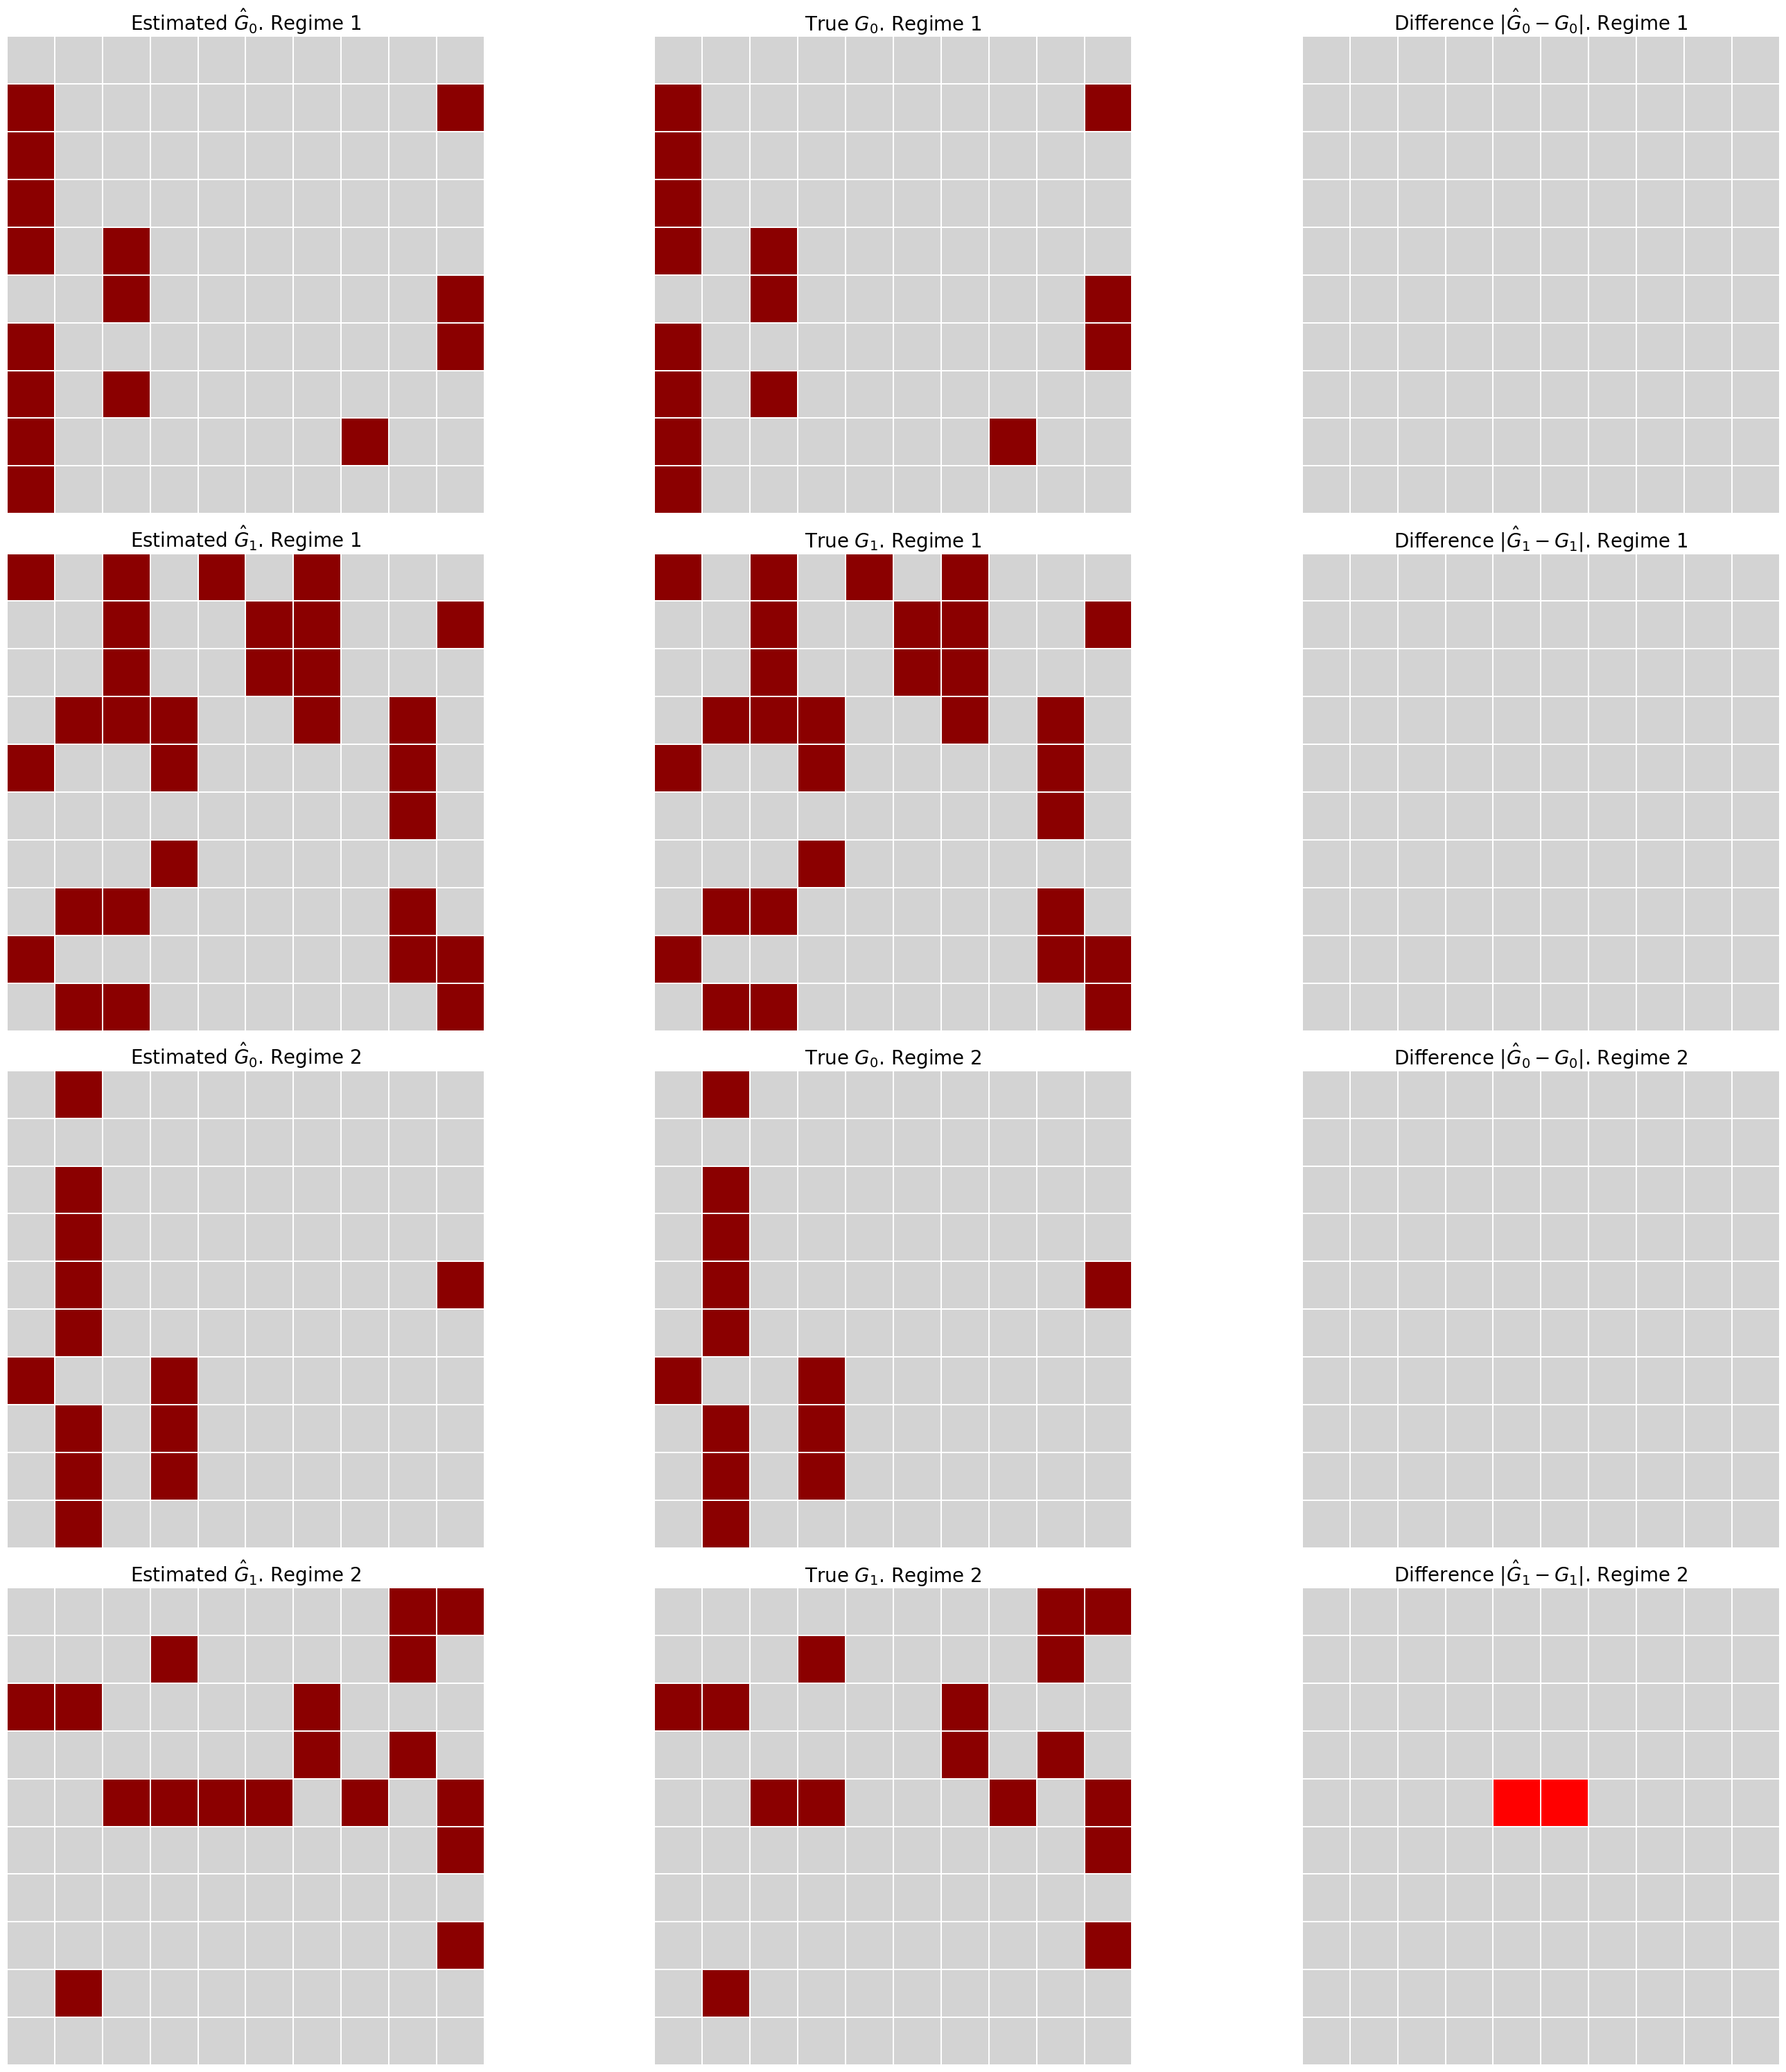

In [94]:
plt_fig(2,g_list,adj_mat, node)

In [95]:
import networkx as nx
def define_big_mat(N,regime, L,g_list,tr_lab):
            if tr_lab ==False:
                        all_estimated_g = np.zeros((N*regime,N*regime))
                        all_estimated_g_lag = np.zeros((N*regime,N*regime))
                        for i in range(regime):
                                    all_estimated_g[i*N:(i+1)*N,i*N:(i+1)*N] = L[i][0]

                             
                             
                                    all_estimated_g_lag[i*N:(i+1)*N,i*N:(i+1)*N] = L[i][1]
                        all_estimated_g[all_estimated_g<0.4] = 0
                        all_estimated_g[all_estimated_g>0.4] = 1

                        all_estimated_g_lag[all_estimated_g_lag<0.4] = 0
                        all_estimated_g_lag[all_estimated_g_lag>0.4] = 1
                        return all_estimated_g,all_estimated_g_lag
            else:
                        g_3_regime = np.zeros((N*regime,N*regime))
                        g_3_regime_lag = np.zeros((N*regime,N*regime))
                        for i in range(regime):
                                    g_3_regime[(i)*N:(i+1)*N,(i)*N:(i+1)*N] = nx.to_numpy_array(g_list[i])[N:2*N,N:2*N]
                                    g_3_regime_lag[(i)*N:(i+1)*N,(i)*N:(i+1)*N] = nx.to_numpy_array(g_list[i])[:N,N:2*N]
                                    #g_3_regime[(i)*N:(i+1)*N,(i)*N:(i+1)*N] = g_list[i][N:2*N,N:2*N]
                                    #g_3_regime_lag[(i)*N:(i+1)*N,(i)*N:(i+1)*N] = g_list[i][:N,N:2*N]
                        return g_3_regime,g_3_regime_lag

In [96]:

all_estimated_g,all_estimated_g_lag = define_big_mat(node,n_reg, adj_mat,g_list,False)
g_3_regime,g_3_regime_lag = define_big_mat(node,n_reg, adj_mat, g_list,True)

In [97]:
shd(g_3_regime,all_estimated_g), classification_metrics(g_3_regime,all_estimated_g.astype(int))['f1']

(0.0, 1.0)

In [98]:
shd(g_3_regime_lag,all_estimated_g_lag), classification_metrics(g_3_regime_lag,all_estimated_g_lag.astype(int))['f1']

(2.0, 0.9787234042553191)

In [99]:
def normalized_hamming_distance(prediction, target):
  '''
  prediction and target are edge lists
  calculate the normalized hamming distance

  For a graph with m nodes, the distance is given by ∑m i,j=1 1 m2 1Gij 6=G′ ij , 
  the number of edges that are present in one graph but not the other, 
  divided by the total number of all possible edges.
  '''
  prediction = set(prediction)
  target = set(target)
  total_nodes = set()
  for i,j in target:
    total_nodes.add(i)
    total_nodes.add(j)
  no_overlap = len(prediction.union(target)) - len(prediction.intersection(target))
  nhd = no_overlap / (len(total_nodes) ** 2)
  reference_nhd = (len(prediction) + len(target))/ (len(total_nodes) ** 2)
  return nhd, reference_nhd, nhd / reference_nhd

In [100]:
def adj_mat_to_edge_list(adj_mat):
    n = adj_mat.shape[0]
    edge_list = []
    for i in range(n):
        for j in range(n):
            if adj_mat[i][j] == 1:
                edge_list.append((i, j))
    return edge_list

In [101]:
normalized_hamming_distance(adj_mat_to_edge_list(all_estimated_g), adj_mat_to_edge_list(g_3_regime))

(0.0, 0.14, 0.0)

In [102]:
normalized_hamming_distance(adj_mat_to_edge_list(all_estimated_g_lag), adj_mat_to_edge_list(g_3_regime_lag))

(0.005, 0.235, 0.021276595744680854)

# Fantom Regime Accuracy:

In [103]:
list_dur  = np.array([0,2500,5500,6500]).astype(int)
true_label = np.zeros((list_dur[n_reg],n_reg))
for i in range(n_reg):
            true_label[list_dur[i]:list_dur[i+1],i] = np.ones(list_dur[i+1] - list_dur[i])

In [104]:
accuracy_score(true_label,gamma_hat ),roc_auc_score(true_label,gamma_hat )

(0.9852727272727273, 0.9842)

# CASTOR evaluation (Baseline):

In [159]:
from CASTOR import CASTOR_1, define_big_mat_CASTOR

In [160]:
n_nodes = 10
lag = False
if lag == True:
            rearange_intra = [str(i)+"_lag0" for i in range(n_nodes)]
            rearange_inter1 = [str(i)+"_lag1" for i in range(n_nodes)]
            rearange_inter2 = [str(i)+"_lag2" for i in range(n_nodes)]
            rearange_inter = rearange_inter1 + rearange_inter2
else:
            rearange_intra = [str(i)+"_lag0" for i in range(n_nodes)]
            rearange_inter = [str(i)+"_lag1" for i in range(n_nodes)]

In [161]:
X = df_total[rearange_intra+rearange_inter].to_numpy()

#X = (X - X.mean())/X.std()
gamma_hat, model_n = CASTOR_1(X, 4, 2, 4000,torch.device('cuda:1'), 1.5,2500)

KeyboardInterrupt: 

# CASTOR with regime labels:

In [162]:
list_dur  = np.array([0,5000,12000,18000]).astype(int)
n_reg = 3
list_model = []
X = df_total[rearange_intra+rearange_inter].to_numpy()
for i in range(n_reg):
            _, model_n = CASTOR_1(X[list_dur[i]:list_dur[i+1]], 1, 2, list_dur[i+1] - list_dur[i],torch.device('cuda:1'), 1.5,0)
            list_model.append(model_n)

/home/arahmani/causal_discovery/cagam/rhino_cnf/CASTOR.py:101: RuntimeWarning: invalid value encountered in divide
  idx = np.argmax(gamma_hat/pall.reshape((m,1)), axis=-1)
/home/arahmani/causal_discovery/cagam/rhino_cnf/CASTOR.py:60: UserWarning: Implicit dimension choice for softmax has been deprecated. Change the call to include dim=X as an argument.
  return soft(y_pre),loss.item(),model


-0.0
[5000.] iter: 0 , p: [5000.]
-0.0
[7000.] iter: 0 , p: [7000.]
-0.0
[6000.] iter: 0 , p: [6000.]


In [163]:
def define_big_mat_CASTOR(N,regime, L,g_list,tr_lab, thresh_inst, thres_lag):
            if tr_lab ==False:
                        all_estimated_g = np.zeros((N*regime,N*regime))
                        all_estimated_g_lag = np.zeros((N*regime,N*regime))
                        for i in range(regime):
                                    all_estimated_g[i*N:(i+1)*N,i*N:(i+1)*N] = L[:N,:N,i]
            
                                    all_estimated_g_lag[i*N:(i+1)*N,i*N:(i+1)*N] = L[N:2*N,:N,i]
                        all_estimated_g[all_estimated_g<thresh_inst] = 0
                        all_estimated_g[all_estimated_g>thresh_inst] = 1

                        all_estimated_g_lag[all_estimated_g_lag<thres_lag] = 0
                        all_estimated_g_lag[all_estimated_g_lag>thres_lag] = 1
                        return all_estimated_g,all_estimated_g_lag
            else:
                        g_3_regime = np.zeros((N*regime,N*regime))
                        g_3_regime_lag = np.zeros((N*regime,N*regime))
                        for i in range(regime):
                                    g_3_regime[(i)*N:(i+1)*N,(i)*N:(i+1)*N] = nx.to_numpy_array(g_list[i])[N:2*N,N:2*N]
                                    g_3_regime_lag[(i)*N:(i+1)*N,(i)*N:(i+1)*N] = nx.to_numpy_array(g_list[i])[:N,N:2*N]
                        return g_3_regime,g_3_regime_lag

In [164]:
lags = 2
reg_num = 3
n_nodes = 10
L = np.zeros((lags*n_nodes, lags*n_nodes, reg_num))
w_thres_l = [0.0,0.,0.6,0.2]
A_thres_l = [0,0,0.,0.3]
for i,class_idx in enumerate(np.arange(reg_num)):#,2,3])):#,3,4])):
            L[:n_nodes, :n_nodes, i] = np.array((abs(list_model[class_idx][0].W_no_thres) > w_thres_l[i]).astype(int)) 
            L[n_nodes:lags*n_nodes,:n_nodes, i] = (abs(list_model[class_idx][0].A_no_thres)> A_thres_l[i]).astype(int)

In [165]:
all_estimated_g,all_estimated_g_lag = define_big_mat_CASTOR(n_nodes,reg_num, L,g_list,False,0,0)
g_3_regime,g_3_regime_lag = define_big_mat_CASTOR(n_nodes,reg_num, L, g_list,True,0,0)

In [166]:
shd(g_3_regime,all_estimated_g), classification_metrics(g_3_regime,all_estimated_g.astype(int))['f1']

(108.0, 0.2469135802469136)

In [167]:
shd(g_3_regime_lag,all_estimated_g_lag), classification_metrics(g_3_regime_lag,all_estimated_g_lag.astype(int))['f1']

(137.0, 0.3353293413173652)

In [168]:
normalized_hamming_distance(adj_mat_to_edge_list(all_estimated_g), adj_mat_to_edge_list(g_3_regime))

(0.20333333333333334, 0.27, 0.7530864197530864)

In [169]:
normalized_hamming_distance(adj_mat_to_edge_list(all_estimated_g_lag), adj_mat_to_edge_list(g_3_regime_lag))

(0.24666666666666667, 0.3711111111111111, 0.6646706586826348)